Import the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import LinearRegression


Load the data

In [3]:
data = pd.read_csv('real_estate_price_size_year.csv')
data.head()

,price,size,year
0,234314.144,643.09,2015
1,228581.528,656.22,2009
2,281626.336,487.29,2018
3,401255.608,1504.75,2015
4,458674.256,1275.46,2009


Create the regression

Declare the dependent and independent variables

In [6]:
x = data[['size','year']]
y = data['price']

Standardize

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

In [8]:
# 回帰

In [10]:
reg = LinearRegression()
reg.fit(x_scaled,y)

LinearRegression()

In [11]:
#切片
reg.intercept_

np.float64(292289.4701599997)

In [14]:
#係数、傾き
reg.coef_

array([67501.57614152, 13724.39708231])

In [15]:
#決定係数
reg.score(x_scaled,y)

0.7764803683276793

In [16]:
#自由度修正済み決定係数

def adj_r2(x,y):
  r2 = reg.score(x,y)
  n = x.shape[0]
  p = x.shape[1]
  adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
  return adjusted_r2

In [17]:
adj_r2(x_scaled,y)

0.77187171612825

In [18]:
new_data = [[750,2009]]
new_data_scaled = scaler.transform(new_data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [19]:
reg.predict(new_data_scaled)

array([258330.34465995])

In [20]:
#それぞれの変数のp値
from sklearn.feature_selection import f_regression

In [21]:
f_regression(x_scaled,y)

(array([285.92105192,   0.85525799]), array([8.12763222e-31, 3.57340758e-01]))

In [23]:
p_values = f_regression(x,y)[1]
p_values

array([8.12763222e-31, 3.57340758e-01])

In [25]:
p_values.round(3)

array([0.   , 0.357])

In [26]:
#summary
reg_summary = pd.DataFrame(data = x.columns.values, columns=['Features'])
reg_summary['Coefficients'] = reg.coef_
reg_summary['p-values'] = p_values.round(3)
reg_summary

,Features,Coefficients,p-values
0,size,67501.576142,0.000
1,year,13724.397082,0.357


In [ ]:
x.shape

(100,)

In [ ]:
y.shape

(100,)

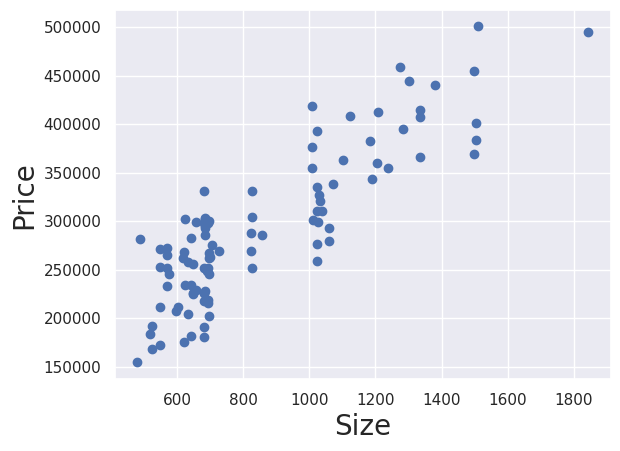

In [ ]:
plt.scatter(x,y)
plt.xlabel('Size', fontsize = 20)
plt.ylabel('Price', fontsize = 20)
plt.show()

In [ ]:
x_matrix = x.values.reshape(-1,1)
x_matrix.shape

(100, 1)

Regression itself

In [ ]:
reg = LinearRegression()

In [ ]:
reg.fit(x_matrix,y)

LinearRegression()

R-squared

In [ ]:
reg.score(x_matrix,y)

0.7447391865847586

Coefficients

In [ ]:
reg.coef_

array([223.17874259])

Intercept

In [ ]:
reg.intercept_

np.float64(101912.60180122897)

Making predictions

In [ ]:
reg.predict([[750]])

array([269296.65874718])

In [ ]:
new_data = pd.DataFrame(data=[1740,1760],columns=['SAT'])
new_data

,SAT
0,1740
1,1760


In [ ]:
reg.predict(new_data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([3.15593751, 3.18905127])

In [ ]:
new_data['Predicted_GPA'] = reg.predict(new_data)
new_data

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,SAT,Predicted_GPA
0,1740,3.155938
1,1760,3.189051


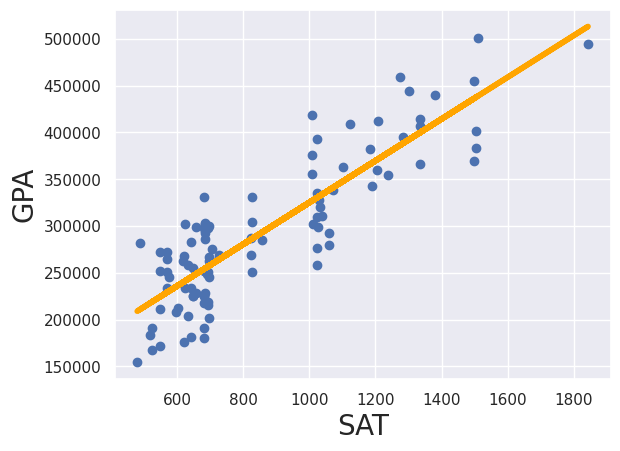

In [ ]:
plt.scatter(x,y)
yhat = reg.coef_*x_matrix + reg.intercept_
#yhat = 0.0017*x + 0.275
fig = plt.plot(x,yhat, lw=4, c='orange', label = 'regression line')
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()